# DATA 501 — Python Module Project
## Ride Knox, One Year Later: “Did the Day Pass Work?”

**Name:** RAYMOND KOJO KYEI
**NetID:** rkyei

### Project Goal
This project evaluates Ride Knox operations using 2025 and January–June 2026 trip and station data. The analysis investigates whether non-member ridership recovered after the introduction of the Day Pass, whether station-capacity changes relieved pressure, how the new and previously low-use stations are performing, and how Day Pass riders compare behaviorally with members and casual riders.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the raw 2026 files
trips_2026_raw = pd.read_csv("trips_2026_h1.csv")
stations_2026_raw = pd.read_excel("stations_2026.xlsx")

# Create working copies so the raw data remain untouched
trips_2026 = trips_2026_raw.copy()
stations_2026 = stations_2026_raw.copy()

## Part A — Intake and Cleaning of the 2026 Data

### A1. Initial Inspection

Before cleaning, I inspected both 2026 files independently rather than assuming that they contain the same issues as the 2025 data. The goal of this inspection is to identify data types, missing values, duplicates, inconsistent categories, and other potential quality problems before making any cleaning decisions.

In [2]:
print("TRIPS 2026 SHAPE")
print(trips_2026.shape)

print("\nSTATIONS 2026 SHAPE")
print(stations_2026.shape)

print("\nFIRST 5 TRIP ROWS")
print(trips_2026.head())

print("\nFIRST 5 STATION ROWS")
print(stations_2026.head())

print("\nTRIP COLUMN TYPES")
print(trips_2026.dtypes)

print("\nSTATION COLUMN TYPES")
print(stations_2026.dtypes)

TRIPS 2026 SHAPE
(137341, 8)

STATIONS 2026 SHAPE
(25, 7)

FIRST 5 TRIP ROWS
    trip_id           start_time             end_time start_station_id  \
0  T0418495  2026-01-01 00:27:32  2026-01-01 00:35:34              S05   
1  T0316555  2026-01-01 01:00:29  2026-01-01 01:20:59              S05   
2  T0388966  2026-01-01 01:08:12  2026-01-01 01:17:50              S22   
3  T0313803  2026-01-01 01:21:39  2026-01-01 01:47:57              S21   
4  T0425615  2026-01-01 01:51:41  2026-01-01 02:08:42              S02   

       start_station_name end_station_id rider_type bike_type  
0       World's Fair Park            S04     casual  electric  
1       World's Fair Park            S11     casual   classic  
2              Tyson Park            S02     member  electric  
3            Caswell Park            S21     casual  electric  
4  Gay Street & Union Ave            S02     casual   classic  

FIRST 5 STATION ROWS
  station_id            station_name       neighborhood  latitude  longi

In [3]:
print("MISSING VALUES — TRIPS")
print(trips_2026.isna().sum())

print("\nMISSING VALUES — STATIONS")
print(stations_2026.isna().sum())

print("\nEXACT DUPLICATE TRIP ROWS")
print(trips_2026.duplicated().sum())

print("\nDUPLICATE TRIP IDs")
print(trips_2026["trip_id"].duplicated().sum())

print("\nEXACT DUPLICATE STATION ROWS")
print(stations_2026.duplicated().sum())

print("\nDUPLICATE STATION IDs")
print(stations_2026["station_id"].duplicated().sum())

print("\nRIDER TYPE VALUES")
print(trips_2026["rider_type"].value_counts(dropna=False))

print("\nBIKE TYPE VALUES")
print(trips_2026["bike_type"].value_counts(dropna=False))

print("\nSTART STATION IDS")
print(trips_2026["start_station_id"].value_counts().sort_index())

print("\nSTATION DIRECTORY")
print(stations_2026)

MISSING VALUES — TRIPS
trip_id                  0
start_time               0
end_time               804
start_station_id         0
start_station_name       0
end_station_id        3999
rider_type               0
bike_type                0
dtype: int64

MISSING VALUES — STATIONS
station_id        0
station_name      0
neighborhood      0
latitude          0
longitude         0
docks             0
year_installed    0
dtype: int64

EXACT DUPLICATE TRIP ROWS
350

DUPLICATE TRIP IDs
350

EXACT DUPLICATE STATION ROWS
0

DUPLICATE STATION IDs
0

RIDER TYPE VALUES
rider_type
member      80684
casual      45685
day_pass     6099
Day Pass     3324
DAY PASS     1549
Name: count, dtype: int64

BIKE TYPE VALUES
bike_type
classic     84973
electric    52368
Name: count, dtype: int64

START STATION IDS
start_station_id
S01    12511
S02     9050
S03     5834
S04     7800
S05     8413
S06    12504
S07     6942
S08    12062
S09     6882
S10     3956
S11     9063
S12     4437
S13     3222
S14     4395
S1

### A2. Investigation of Data-Quality Issues

The initial inspection identified several issues that require investigation before cleaning: exact duplicate trip rows, inconsistent Day Pass labels, missing end times, missing end-station IDs, and possible inconsistencies in station names. Because the 2026 data team also reported an undocumented January app bug, I examined the timing and pattern of these issues before deciding how to handle them.

In [4]:
# Convert timestamps temporarily for investigation
trips_2026["start_time"] = pd.to_datetime(trips_2026["start_time"])
trips_2026["end_time"] = pd.to_datetime(trips_2026["end_time"])

# Calculate trip duration in minutes
trips_2026["duration_min"] = (
    (trips_2026["end_time"] - trips_2026["start_time"])
    .dt.total_seconds() / 60
)

print("MISSING END TIMES")
print(trips_2026["end_time"].isna().sum())

print("\nSTART-DATE RANGE OF MISSING END TIMES")
print(
    trips_2026.loc[
        trips_2026["end_time"].isna(), "start_time"
    ].min()
)
print(
    trips_2026.loc[
        trips_2026["end_time"].isna(), "start_time"
    ].max()
)

print("\nMISSING END TIMES BY MONTH")
print(
    trips_2026.loc[
        trips_2026["end_time"].isna()
    ]
    .groupby(trips_2026["start_time"].dt.month)
    .size()
)

print("\nTRIPS SHORTER THAN 1 MINUTE")
print((trips_2026["duration_min"] < 1).sum())

print("\nTRIPS LONGER THAN 24 HOURS")
print((trips_2026["duration_min"] > 24 * 60).sum())

print("\nMINIMUM DURATION")
print(trips_2026["duration_min"].min())

print("\nMAXIMUM DURATION")
print(trips_2026["duration_min"].max())

MISSING END TIMES
804

START-DATE RANGE OF MISSING END TIMES
2026-01-05 07:40:35
2026-02-09 22:35:00

MISSING END TIMES BY MONTH
start_time
1    535
2    269
dtype: int64

TRIPS SHORTER THAN 1 MINUTE
342

TRIPS LONGER THAN 24 HOURS
240

MINIMUM DURATION
-92.61666666666666

MAXIMUM DURATION
4784.733333333334


In [5]:
print("MISSING END STATION IDs")
print(trips_2026["end_station_id"].isna().sum())

print("\nMISSING END TIME AND MISSING END STATION")
print(
    (
        trips_2026["end_time"].isna()
        & trips_2026["end_station_id"].isna()
    ).sum()
)

print("\nMISSING END STATION BUT END TIME PRESENT")
print(
    (
        trips_2026["end_time"].notna()
        & trips_2026["end_station_id"].isna()
    ).sum()
)

print("\nMISSING END TIME BUT END STATION PRESENT")
print(
    (
        trips_2026["end_time"].isna()
        & trips_2026["end_station_id"].notna()
    ).sum()
)

MISSING END STATION IDs
3999

MISSING END TIME AND MISSING END STATION
19

MISSING END STATION BUT END TIME PRESENT
3980

MISSING END TIME BUT END STATION PRESENT
785


In [6]:
print("UNIQUE START-STATION NAMES BEFORE STRIPPING")
print(trips_2026["start_station_name"].nunique())

print("\nROWS WITH LEADING/TRAILING WHITESPACE")
print(
    (
        trips_2026["start_station_name"]
        != trips_2026["start_station_name"].str.strip()
    ).sum()
)

print("\nUNIQUE START-STATION NAMES AFTER STRIPPING")
print(
    trips_2026["start_station_name"]
    .str.strip()
    .nunique()
)

UNIQUE START-STATION NAMES BEFORE STRIPPING
50

ROWS WITH LEADING/TRAILING WHITESPACE
1691

UNIQUE START-STATION NAMES AFTER STRIPPING
25


### A2. Findings and Cleaning Decisions

The inspection showed several distinct data-quality issues rather than one single problem.

1. **Exact duplicates:** There are 350 exact duplicate trip rows, and the number of duplicated trip IDs is also 350. I will remove the exact duplicate rows because they appear to be repeated submissions of the same trip rather than separate rides. An alternative would be to keep them, but that would inflate trip counts.

2. **Rider-type labels:** The Day Pass appears as `day_pass`, `Day Pass`, and `DAY PASS`. I will standardize rider-type text to lowercase and convert spaces to underscores so all three represent the single category `day_pass`. Keeping the labels separate would incorrectly treat one product as three rider groups.

3. **Station names:** There are 1,691 rows with leading or trailing whitespace in the raw data, producing 50 apparent station names instead of 25. I will strip whitespace from station names. The station IDs show that these are formatting differences, not different stations.

4. **Missing end-station IDs:** Missing end-station information affects many trips, but those records still contain valid start-station and rider information. I will keep these rows and create a `no_end_station` flag rather than deleting them.

5. **Missing and invalid durations:** Some trips have missing end times, durations below 1 minute, negative durations, or durations longer than 24 hours. These records may still be useful for ridership and start-station counts, so I will not delete them globally. Instead, I will create a `valid_duration` flag and restrict duration-based analyses to valid-duration trips.

6. **January app bug:** Missing end times are concentrated from January 5 through February 9, consistent with the documented January app problem. Because the exact corruption mechanism is unknown, I will avoid trying to reconstruct or impute end times and will instead preserve the records while flagging their duration as unusable.

### A3. Cleaning the 2026 Trip Data and Row-Count Audit Trail

In [7]:
# Start again from the untouched raw data
trips_2026_clean = trips_2026_raw.copy()

print("ROW-COUNT AUDIT TRAIL")
print("Raw rows:", len(trips_2026_clean))

# 1. Remove exact duplicate rows
before = len(trips_2026_clean)

trips_2026_clean = trips_2026_clean.drop_duplicates()

after = len(trips_2026_clean)

print("\nAfter removing exact duplicates:", after)
print("Rows removed:", before - after)

# 2. Standardize rider type
trips_2026_clean["rider_type"] = (
    trips_2026_clean["rider_type"]
    .str.strip()
    .str.lower()
    .str.replace(" ", "_", regex=False)
)

# 3. Standardize start-station names
trips_2026_clean["start_station_name"] = (
    trips_2026_clean["start_station_name"]
    .str.strip()
)

# 4. Convert timestamps
trips_2026_clean["start_time"] = pd.to_datetime(
    trips_2026_clean["start_time"]
)

trips_2026_clean["end_time"] = pd.to_datetime(
    trips_2026_clean["end_time"]
)

# 5. Calculate duration
trips_2026_clean["duration_min"] = (
    (
        trips_2026_clean["end_time"]
        - trips_2026_clean["start_time"]
    ).dt.total_seconds()
    / 60
)

# 6. Preserve missing end-station information as a flag
trips_2026_clean["no_end_station"] = (
    trips_2026_clean["end_station_id"].isna()
)

# 7. Flag valid durations instead of globally deleting rows
trips_2026_clean["valid_duration"] = (
    trips_2026_clean["duration_min"].between(1, 24 * 60)
)

# 8. Create useful date/time fields
trips_2026_clean["month"] = (
    trips_2026_clean["start_time"].dt.month
)

trips_2026_clean["hour"] = (
    trips_2026_clean["start_time"].dt.hour
)

trips_2026_clean["day_name"] = (
    trips_2026_clean["start_time"].dt.day_name()
)

trips_2026_clean["is_weekend"] = (
    trips_2026_clean["day_name"]
    .isin(["Saturday", "Sunday"])
)

print("\nFinal cleaned trip rows:", len(trips_2026_clean))

print("\nRider types after standardization:")
print(trips_2026_clean["rider_type"].value_counts())

print("\nTrips with no end station:")
print(trips_2026_clean["no_end_station"].value_counts())

print("\nValid-duration flag:")
print(trips_2026_clean["valid_duration"].value_counts())

ROW-COUNT AUDIT TRAIL
Raw rows: 137341

After removing exact duplicates: 136991
Rows removed: 350

Final cleaned trip rows: 136991

Rider types after standardization:
rider_type
member      80464
casual      45586
day_pass    10941
Name: count, dtype: int64

Trips with no end station:
no_end_station
False    133001
True       3990
Name: count, dtype: int64

Valid-duration flag:
valid_duration
True     135611
False      1380
Name: count, dtype: int64


In [8]:
print("START STATION IDS NOT FOUND IN 2026 DIRECTORY")
print(
    (
        ~trips_2026_clean["start_station_id"]
        .isin(stations_2026["station_id"])
    ).sum()
)

print("\nNON-MISSING END STATION IDS NOT FOUND IN DIRECTORY")
print(
    (
        trips_2026_clean["end_station_id"].notna()
        &
        ~trips_2026_clean["end_station_id"]
        .isin(stations_2026["station_id"])
    ).sum()
)

# Check whether cleaned start-station names match directory names
station_check = pd.merge(
    trips_2026_clean[
        ["start_station_id", "start_station_name"]
    ],
    stations_2026[
        ["station_id", "station_name"]
    ],
    left_on="start_station_id",
    right_on="station_id",
    how="left"
)

print("\nSTART-STATION NAME MISMATCHES AFTER CLEANING")
print(
    (
        station_check["start_station_name"]
        != station_check["station_name"]
    ).sum()
)

START STATION IDS NOT FOUND IN 2026 DIRECTORY
0

NON-MISSING END STATION IDS NOT FOUND IN DIRECTORY
0

START-STATION NAME MISMATCHES AFTER CLEANING
0


### A4. Validation of the 2026 Station Directory

The station directory contained no missing values, duplicate station rows, or duplicate station IDs. I also verified the known 2026 operational changes before using the station data in later comparisons.

In [9]:
print("NUMBER OF STATIONS")
print(len(stations_2026))

print("\nS06, S08, AND S25 DETAILS")
print(
    stations_2026[
        stations_2026["station_id"].isin(["S06", "S08", "S25"])
    ][
        ["station_id", "station_name", "neighborhood", "docks", "year_installed"]
    ]
)

print("\nSTATIONS WITH NON-POSITIVE DOCK COUNTS")
print((stations_2026["docks"] <= 0).sum())

print("\nDOCK COUNT RANGE")
print(stations_2026["docks"].min())
print(stations_2026["docks"].max())

NUMBER OF STATIONS
25

S06, S08, AND S25 DETAILS
   station_id              station_name  neighborhood  docks  year_installed
5         S06            Hodges Library     UT Campus     32            2022
7         S08        Student Union - UT     UT Campus     32            2022
24        S25  Cumberland Ave & 22nd St  Fort Sanders     16            2026

STATIONS WITH NON-POSITIVE DOCK COUNTS
0

DOCK COUNT RANGE
10
32


In [10]:
print("FINAL 2026 CLEANING AUDIT")

print("\nRows:")
print("Raw:", len(trips_2026_raw))
print("Clean:", len(trips_2026_clean))
print("Removed:", len(trips_2026_raw) - len(trips_2026_clean))

print("\nRemaining exact duplicates:")
print(trips_2026_clean.duplicated().sum())

print("\nRemaining duplicate trip IDs:")
print(trips_2026_clean["trip_id"].duplicated().sum())

print("\nRider types:")
print(trips_2026_clean["rider_type"].value_counts())

print("\nMissing end stations:")
print(trips_2026_clean["no_end_station"].sum())

print("\nValid durations:")
print(trips_2026_clean["valid_duration"].value_counts())

print("\nCleaned date range:")
print(trips_2026_clean["start_time"].min())
print(trips_2026_clean["start_time"].max())

FINAL 2026 CLEANING AUDIT

Rows:
Raw: 137341
Clean: 136991
Removed: 350

Remaining exact duplicates:
0

Remaining duplicate trip IDs:
0

Rider types:
rider_type
member      80464
casual      45586
day_pass    10941
Name: count, dtype: int64

Missing end stations:
3990

Valid durations:
valid_duration
True     135611
False      1380
Name: count, dtype: int64

Cleaned date range:
2026-01-01 00:27:32
2026-06-30 23:54:06


### A5. Final Cleaning Summary

The 2026 trip file began with 137,341 rows. I removed 350 exact duplicate records, leaving 136,991 unique trips. No other rows were globally deleted because records with missing destination information or invalid durations still contain useful evidence about trip starts, rider type, and station use.

Rider-type labels were standardized to `member`, `casual`, and `day_pass`, and start-station names were stripped of whitespace. Missing end-station IDs were preserved using a `no_end_station` flag. Duration quality was handled with a `valid_duration` flag: 135,611 trips have durations between 1 minute and 24 hours, while 1,380 do not. Duration-based analyses will use only valid-duration trips, whereas ridership counts and start-station analyses will retain the broader cleaned trip dataset.

All start-station IDs and all non-missing end-station IDs match the 2026 station directory, and cleaned start-station names match the directory exactly. The 2026 station directory contains 25 stations, including the expanded S06 and S08 stations and the new S25 station.

## Part B — Did Non-Member Ridership Recover?

### B1. Fair 2025 Baseline

Because the 2026 file covers only January through June, the fair comparison is January–June 2025 versus January–June 2026. I therefore rebuild the 2025 data using the previously established cleaning rules and restrict the baseline to the same six-month period.

In [11]:
# Load the 2025 baseline data
trips_2025_raw = pd.read_csv("trips_2025.csv")

# Start from a copy
trips_2025_clean = trips_2025_raw.copy()

# Remove exact duplicates
trips_2025_clean = trips_2025_clean.drop_duplicates()

# Remove the known 2025 test station
trips_2025_clean = trips_2025_clean[
    trips_2025_clean["start_station_id"] != "S99"
]

# Standardize rider type
trips_2025_clean["rider_type"] = (
    trips_2025_clean["rider_type"]
    .str.strip()
    .str.lower()
)

# Standardize station names
trips_2025_clean["start_station_name"] = (
    trips_2025_clean["start_station_name"]
    .str.strip()
    .str.title()
)

# Convert timestamps
trips_2025_clean["start_time"] = pd.to_datetime(
    trips_2025_clean["start_time"]
)

trips_2025_clean["end_time"] = pd.to_datetime(
    trips_2025_clean["end_time"]
)

# Calculate duration
trips_2025_clean["duration_min"] = (
    (
        trips_2025_clean["end_time"]
        - trips_2025_clean["start_time"]
    ).dt.total_seconds()
    / 60
)

# Use a validity flag, matching the 2026 approach
trips_2025_clean["valid_duration"] = (
    trips_2025_clean["duration_min"].between(1, 24 * 60)
)

# Add month
trips_2025_clean["month"] = (
    trips_2025_clean["start_time"].dt.month
)

# Match the 2026 time window: January through June
trips_2025_h1 = trips_2025_clean[
    trips_2025_clean["month"] <= 6
].copy()

print("2025 H1 comparable rows:", len(trips_2025_h1))
print("2026 H1 comparable rows:", len(trips_2026_clean))

print("\n2025 rider types:")
print(trips_2025_h1["rider_type"].value_counts())

print("\n2026 rider types:")
print(trips_2026_clean["rider_type"].value_counts())

2025 H1 comparable rows: 131011
2026 H1 comparable rows: 136991

2025 rider types:
rider_type
member    73387
casual    57624
Name: count, dtype: int64

2026 rider types:
rider_type
member      80464
casual      45586
day_pass    10941
Name: count, dtype: int64


### B2. Defining Non-Member Recovery

The Day Pass creates a definition problem that did not exist in 2025. In 2025, non-member riders were recorded only as `casual`, whereas in 2026 some non-members can appear as either `casual` or `day_pass`.

I therefore evaluate recovery in two ways:

1. **Casual-only recovery:** compare 2026 casual trips directly with 2025 casual trips.
2. **Broad non-member recovery:** compare 2026 casual + Day Pass trips with 2025 casual trips.

The second definition treats Day Pass use as part of the non-member market the product was intended to recover. Showing both definitions prevents the conclusion from depending on an unstated classification choice.

In [12]:
# 2025 monthly casual counts
casual_2025_monthly = (
    trips_2025_h1[
        trips_2025_h1["rider_type"] == "casual"
    ]
    .groupby("month")
    .size()
)

# 2026 monthly casual counts
casual_2026_monthly = (
    trips_2026_clean[
        trips_2026_clean["rider_type"] == "casual"
    ]
    .groupby("month")
    .size()
)

# 2026 monthly Day Pass counts
day_pass_2026_monthly = (
    trips_2026_clean[
        trips_2026_clean["rider_type"] == "day_pass"
    ]
    .groupby("month")
    .size()
)

# Build one comparison table
recovery_table = pd.DataFrame({
    "casual_2025": casual_2025_monthly,
    "casual_2026": casual_2026_monthly,
    "day_pass_2026": day_pass_2026_monthly
}).fillna(0)

# Broad 2026 non-member definition
recovery_table["nonmember_2026"] = (
    recovery_table["casual_2026"]
    + recovery_table["day_pass_2026"]
)

# Casual-only year-over-year change
recovery_table["casual_yoy_pct"] = (
    (
        recovery_table["casual_2026"]
        - recovery_table["casual_2025"]
    )
    / recovery_table["casual_2025"]
) * 100

# Broad non-member year-over-year change
recovery_table["nonmember_yoy_pct"] = (
    (
        recovery_table["nonmember_2026"]
        - recovery_table["casual_2025"]
    )
    / recovery_table["casual_2025"]
) * 100

print(recovery_table)

       casual_2025  casual_2026  day_pass_2026  nonmember_2026  \
month                                                            
1             4740         3455            0.0          3455.0   
2             5699         4277            0.0          4277.0   
3             8645         6729         1114.0          7843.0   
4            11331         8940         2248.0         11188.0   
5            13282        10783         3434.0         14217.0   
6            13927        11402         4145.0         15547.0   

       casual_yoy_pct  nonmember_yoy_pct  
month                                     
1          -27.109705         -27.109705  
2          -24.951746         -24.951746  
3          -22.163100          -9.277039  
4          -21.101403          -1.262025  
5          -18.814938           7.039602  
6          -18.130251          11.632082  


In [13]:
casual_2025_h1 = (
    trips_2025_h1["rider_type"] == "casual"
).sum()

casual_2026_h1 = (
    trips_2026_clean["rider_type"] == "casual"
).sum()

day_pass_2026_h1 = (
    trips_2026_clean["rider_type"] == "day_pass"
).sum()

nonmember_2026_h1 = (
    casual_2026_h1 + day_pass_2026_h1
)

casual_h1_change = (
    (casual_2026_h1 - casual_2025_h1)
    / casual_2025_h1
) * 100

nonmember_h1_change = (
    (nonmember_2026_h1 - casual_2025_h1)
    / casual_2025_h1
) * 100

print("2025 H1 casual trips:", casual_2025_h1)
print("2026 H1 casual trips:", casual_2026_h1)
print("2026 H1 Day Pass trips:", day_pass_2026_h1)
print("2026 H1 casual + Day Pass trips:", nonmember_2026_h1)

print("\nCasual-only H1 YoY change (%):")
print(casual_h1_change)

print("\nBroad non-member H1 YoY change (%):")
print(nonmember_h1_change)

2025 H1 casual trips: 57624
2026 H1 casual trips: 45586
2026 H1 Day Pass trips: 10941
2026 H1 casual + Day Pass trips: 56527

Casual-only H1 YoY change (%):
-20.89060113841455

Broad non-member H1 YoY change (%):
-1.9037206719422464


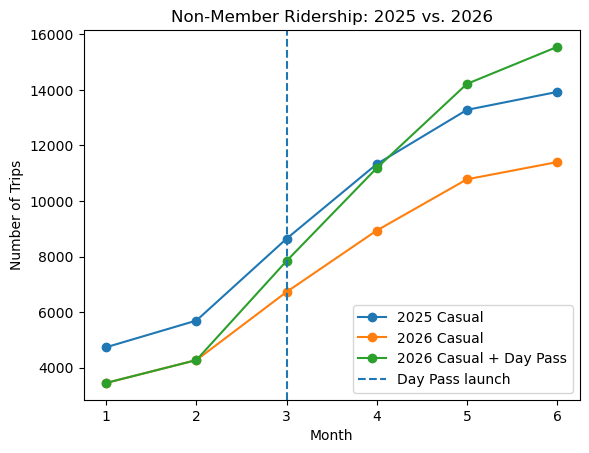

In [14]:
plt.plot(
    recovery_table.index,
    recovery_table["casual_2025"],
    marker="o",
    label="2025 Casual"
)

plt.plot(
    recovery_table.index,
    recovery_table["casual_2026"],
    marker="o",
    label="2026 Casual"
)

plt.plot(
    recovery_table.index,
    recovery_table["nonmember_2026"],
    marker="o",
    label="2026 Casual + Day Pass"
)

plt.axvline(
    x=3,
    linestyle="--",
    label="Day Pass launch"
)

plt.title("Non-Member Ridership: 2025 vs. 2026")
plt.xlabel("Month")
plt.ylabel("Number of Trips")
plt.xticks(range(1, 7))
plt.legend()

plt.savefig(
    "charts/nonmember_recovery.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

### B3. Recovery Verdict

The recovery conclusion depends on how non-member ridership is defined. If I compare only casual single-ride trips, ridership remained 20.9% below the January–June 2025 level. However, when Day Pass trips are included as part of the non-member market, the gap narrows to only 1.9% below 2025 overall.

The month-by-month pattern strengthens this interpretation. Before the Day Pass launch, non-member ridership was 27.1% below 2025 in January and 25.0% below in February. After the March 1 launch, the broad non-member gap narrowed from 9.3% below 2025 in March to 1.3% below in April, then exceeded 2025 levels by 7.0% in May and 11.6% in June.

**Verdict:** The Day Pass appears to have substantially recovered the lost non-member market, although it has not restored casual single-ride use itself. This pattern is consistent with recovery after the product launch, but the observational data do not prove that the Day Pass alone caused the improvement.

## Part C — Capacity Analysis

### C1. Pressure Measure and Comparison Strategy

To compare stations fairly, I use **trips per dock per operating day**:

**Pressure = trip starts / (number of docks × number of operating days)**

This adjusts for both station size and the amount of time a station was available. Raw trip counts alone would make larger stations or stations open for longer periods appear more heavily used even if the actual pressure on each dock was lower.

For S06 and S08, I compare March–June 2025 with March–June 2026. This avoids making an unsupported assumption about the exact February 2026 expansion date and ensures that the 2026 comparison period is fully after the increase from 24 to 32 docks.

For S23 and S24, I compare January–June 2025 with January–June 2026 because both stations operated throughout both periods.

S25 did not exist in 2025, so a direct station-level year-over-year comparison is impossible. I therefore evaluate its March–June 2026 pressure and compare the surrounding Fort Sanders stations before and after S25 opened.

### C2. Verification of Year-Specific Dock Counts

In [15]:
stations_2025 = pd.read_excel("stations.xlsx")

print("2025 TARGET STATIONS")
print(
    stations_2025[
        stations_2025["station_id"].isin(
            ["S06", "S08", "S11", "S12", "S23", "S24"]
        )
    ][
        ["station_id", "station_name", "neighborhood", "docks"]
    ]
)

print("\n2026 TARGET STATIONS")
print(
    stations_2026[
        stations_2026["station_id"].isin(
            ["S06", "S08", "S11", "S12", "S23", "S24", "S25"]
        )
    ][
        ["station_id", "station_name", "neighborhood", "docks"]
    ]
)

2025 TARGET STATIONS
   station_id               station_name    neighborhood  docks
5         S06             Hodges Library       UT Campus     24
7         S08         Student Union - UT       UT Campus     24
10        S11   Cumberland Ave & 17th St    Fort Sanders     16
11        S12  Fort Sanders - Laurel Ave    Fort Sanders     12
22        S23    Bearden - Kingston Pike         Bearden     12
23        S24        Sequoyah Hills Park  Sequoyah Hills     10

2026 TARGET STATIONS
   station_id               station_name    neighborhood  docks
5         S06             Hodges Library       UT Campus     32
7         S08         Student Union - UT       UT Campus     32
10        S11   Cumberland Ave & 17th St    Fort Sanders     16
11        S12  Fort Sanders - Laurel Ave    Fort Sanders     12
22        S23    Bearden - Kingston Pike         Bearden     12
23        S24        Sequoyah Hills Park  Sequoyah Hills     10
24        S25   Cumberland Ave & 22nd St    Fort Sanders     

In [16]:
# Comparable post-expansion window: March through June
trips_2025_mar_jun = trips_2025_clean[
    trips_2025_clean["month"].between(3, 6)
].copy()

trips_2026_mar_jun = trips_2026_clean[
    trips_2026_clean["month"].between(3, 6)
].copy()

campus_ids = ["S06", "S08"]

# Count trip starts
campus_2025_counts = (
    trips_2025_mar_jun[
        trips_2025_mar_jun["start_station_id"].isin(campus_ids)
    ]
    .groupby("start_station_id")
    .size()
)

campus_2026_counts = (
    trips_2026_mar_jun[
        trips_2026_mar_jun["start_station_id"].isin(campus_ids)
    ]
    .groupby("start_station_id")
    .size()
)

campus_pressure = pd.DataFrame({
    "trips_2025": campus_2025_counts,
    "trips_2026": campus_2026_counts
})

# Known dock counts for these periods
campus_pressure["docks_2025"] = 24
campus_pressure["docks_2026"] = 32

operating_days_mar_jun = 122

campus_pressure["pressure_2025"] = (
    campus_pressure["trips_2025"]
    / (
        campus_pressure["docks_2025"]
        * operating_days_mar_jun
    )
)

campus_pressure["pressure_2026"] = (
    campus_pressure["trips_2026"]
    / (
        campus_pressure["docks_2026"]
        * operating_days_mar_jun
    )
)

campus_pressure["pressure_change_pct"] = (
    (
        campus_pressure["pressure_2026"]
        - campus_pressure["pressure_2025"]
    )
    / campus_pressure["pressure_2025"]
) * 100

print(campus_pressure)

                  trips_2025  trips_2026  docks_2025  docks_2026  \
start_station_id                                                   
S06                    11143       10146          24          32   
S08                    10805        9737          24          32   

                  pressure_2025  pressure_2026  pressure_change_pct  
start_station_id                                                     
S06                    3.805669       2.598873           -31.710491  
S08                    3.690232       2.494109           -32.413235  


### C3. Campus Expansion Result

Pressure decreased substantially at both expanded campus stations. S06 fell from 3.81 to 2.60 trip starts per dock per day, a 31.7% reduction, while S08 fell from 3.69 to 2.49, a 32.4% reduction.

**Verdict 1:** The S06/S08 dock expansion appears to have relieved campus pressure. Both stations remained heavily used, but each dock handled substantially fewer trip starts per day after capacity increased.

In [17]:
rookie_ids = ["S23", "S24"]

rookie_2025_counts = (
    trips_2025_h1[
        trips_2025_h1["start_station_id"].isin(rookie_ids)
    ]
    .groupby("start_station_id")
    .size()
)

rookie_2026_counts = (
    trips_2026_clean[
        trips_2026_clean["start_station_id"].isin(rookie_ids)
    ]
    .groupby("start_station_id")
    .size()
)

rookie_pressure = pd.DataFrame({
    "trips_2025": rookie_2025_counts,
    "trips_2026": rookie_2026_counts
})

rookie_pressure["docks_2025"] = (
    stations_2025
    .set_index("station_id")
    .loc[rookie_ids, "docks"]
)

rookie_pressure["docks_2026"] = (
    stations_2026
    .set_index("station_id")
    .loc[rookie_ids, "docks"]
)

operating_days_h1 = 181

rookie_pressure["pressure_2025"] = (
    rookie_pressure["trips_2025"]
    / (rookie_pressure["docks_2025"] * operating_days_h1)
)

rookie_pressure["pressure_2026"] = (
    rookie_pressure["trips_2026"]
    / (rookie_pressure["docks_2026"] * operating_days_h1)
)

rookie_pressure["pressure_change_pct"] = (
    (
        rookie_pressure["pressure_2026"]
        - rookie_pressure["pressure_2025"]
    )
    / rookie_pressure["pressure_2025"]
) * 100

print(rookie_pressure)

                  trips_2025  trips_2026  docks_2025  docks_2026  \
start_station_id                                                   
S23                     1084        2245          12          12   
S24                      987         986          10          10   

                  pressure_2025  pressure_2026  pressure_change_pct  
start_station_id                                                     
S23                    0.499079       1.033610           107.103321  
S24                    0.545304       0.544751            -0.101317  


In [18]:
fort_sanders_2025_ids = ["S11", "S12"]
fort_sanders_2026_ids = ["S11", "S12", "S25"]

fs_2025_counts = (
    trips_2025_mar_jun[
        trips_2025_mar_jun["start_station_id"].isin(
            fort_sanders_2025_ids
        )
    ]
    .groupby("start_station_id")
    .size()
)

fs_2026_counts = (
    trips_2026_mar_jun[
        trips_2026_mar_jun["start_station_id"].isin(
            fort_sanders_2026_ids
        )
    ]
    .groupby("start_station_id")
    .size()
)

fs_2025 = pd.DataFrame({
    "trips": fs_2025_counts
})

fs_2025["docks"] = (
    stations_2025
    .set_index("station_id")
    .loc[fs_2025.index, "docks"]
)

fs_2025["pressure"] = (
    fs_2025["trips"]
    / (fs_2025["docks"] * 122)
)

fs_2026 = pd.DataFrame({
    "trips": fs_2026_counts
})

fs_2026["docks"] = (
    stations_2026
    .set_index("station_id")
    .loc[fs_2026.index, "docks"]
)

fs_2026["pressure"] = (
    fs_2026["trips"]
    / (fs_2026["docks"] * 122)
)

print("FORT SANDERS 2025")
print(fs_2025)

print("\nFORT SANDERS 2026")
print(fs_2026)

FORT SANDERS 2025
                  trips  docks  pressure
start_station_id                        
S11                8185     16  4.193135
S12                4012     12  2.740437

FORT SANDERS 2026
                  trips  docks  pressure
start_station_id                        
S11                7406     16  3.794057
S12                3630     12  2.479508
S25                6427     16  3.292520


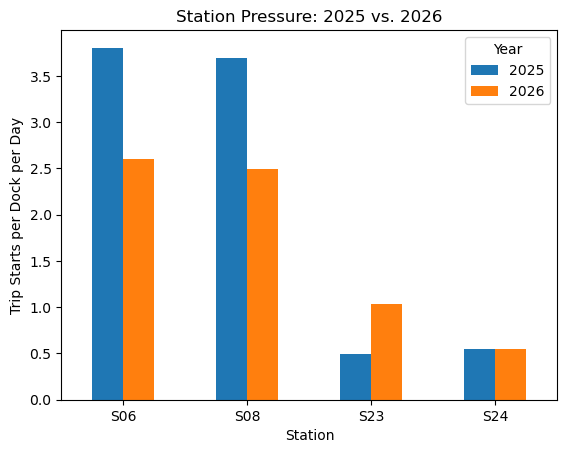

In [19]:
capacity_chart = pd.DataFrame({
    "2025": [
        campus_pressure.loc["S06", "pressure_2025"],
        campus_pressure.loc["S08", "pressure_2025"],
        rookie_pressure.loc["S23", "pressure_2025"],
        rookie_pressure.loc["S24", "pressure_2025"]
    ],
    "2026": [
        campus_pressure.loc["S06", "pressure_2026"],
        campus_pressure.loc["S08", "pressure_2026"],
        rookie_pressure.loc["S23", "pressure_2026"],
        rookie_pressure.loc["S24", "pressure_2026"]
    ]
}, index=["S06", "S08", "S23", "S24"])

capacity_chart.plot(kind="bar")

plt.title("Station Pressure: 2025 vs. 2026")
plt.xlabel("Station")
plt.ylabel("Trip Starts per Dock per Day")
plt.xticks(rotation=0)
plt.legend(title="Year")

plt.savefig(
    "charts/station_pressure_yoy.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

### C4. Year-Two Verdict on S23 and S24

S23 (Bearden) improved substantially from 0.50 to 1.03 trip starts per dock per day, an increase of about 107%. This suggests that its first-year low use was not persistent.

S24 (Sequoyah Hills Park) remained almost unchanged at about 0.55 trip starts per dock per day, with essentially no year-over-year improvement.

**Verdict 2:** Keep S23 because usage has more than doubled. Continue to watch S24 closely; if similarly low use continues, relocation should be considered because a second year of data shows little evidence of growth.

### C5. New Station S25 and the Fort Sanders Recommendation

S25 recorded 6,427 trip starts from March through June 2026, equivalent to 3.29 trip starts per dock per day. This is substantial first-year use: its normalized pressure is already higher than S12 and below only S11 among the three Fort Sanders stations.

Over the same March–June comparison period, S11 declined from 4.19 to 3.79 trip starts per dock per day and S12 declined from 2.74 to 2.48. The addition of S25 therefore coincided with both strong use at the new station and somewhat lower pressure at the existing Fort Sanders stations.

**Verdict 3:** S25 is performing strongly in its first months and supports the 2025 recommendation to add capacity in Fort Sanders. The pattern is consistent with the new station absorbing meaningful demand, although the observational comparison cannot prove that S25 alone caused the decline at S11 and S12.

## Part D — Who Are the Day Pass Riders?

### D1. Behavioral Comparison Strategy

Because the Day Pass launched on March 1, I restrict the behavioral comparison to March–June 2026 so that members, casual riders, and Day Pass riders are compared over the same operating period.

To determine whether Day Pass riders behave more like casual riders or members, I compare the three rider groups using measures that are not distorted by their different group sizes.

I focus on three behaviors:

1. **Trip duration** — typical and longer trips.
2. **Time of day** — whether use follows commute peaks or daytime/leisure patterns.
3. **Weekend use** — the share of each rider group's trips occurring on weekends.

For duration comparisons, I use only trips with `valid_duration == True`. For timing and weekend comparisons, I use all cleaned March–June trip-start records because those measures do not depend on a valid end time.

In [20]:
# Restrict all rider groups to the same March-June 2026 period
profile_2026 = trips_2026_clean[
    trips_2026_clean["month"].between(3, 6)
].copy()

print("March-June 2026 rider counts:")
print(profile_2026["rider_type"].value_counts())

March-June 2026 rider counts:
rider_type
member      65314
casual      37854
day_pass    10941
Name: count, dtype: int64


### D2. Trip Duration

In [21]:
# Use only trips with valid durations
duration_2026 = profile_2026[
    profile_2026["valid_duration"]
].copy()

duration_summary = (
    duration_2026
    .groupby("rider_type")["duration_min"]
    .agg(["count", "mean", "median"])
)

# Add 90th percentile
duration_summary["p90"] = (
    duration_2026
    .groupby("rider_type")["duration_min"]
    .quantile(0.90)
)

print(duration_summary)

            count       mean     median    p90
rider_type                                    
casual      37685  22.915774  19.083333  41.45
day_pass    10886  24.086905  20.533333  43.30
member      65042  13.573267  11.650000  23.80


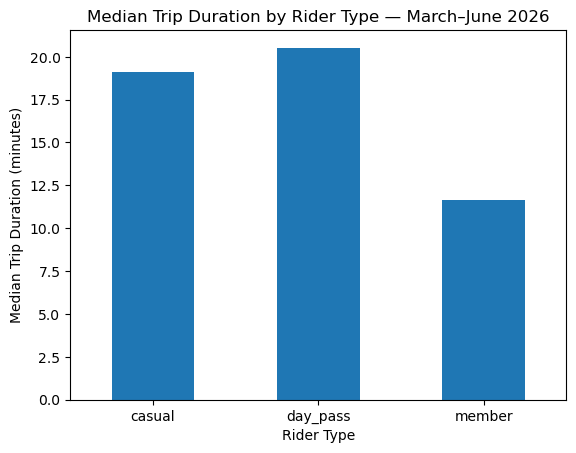

In [22]:
median_duration = (
    duration_2026
    .groupby("rider_type")["duration_min"]
    .median()
)

median_duration.plot(kind="bar")

plt.title("Median Trip Duration by Rider Type — March–June 2026")
plt.xlabel("Rider Type")
plt.ylabel("Median Trip Duration (minutes)")
plt.xticks(rotation=0)

plt.savefig(
    "charts/day_pass_duration_profile.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

### D3. Weekend Use

In [23]:
weekend_summary = (
    profile_2026
    .groupby("rider_type")["is_weekend"]
    .agg(["count", "sum", "mean"])
)

weekend_summary["weekend_pct"] = (
    weekend_summary["mean"] * 100
)

print(weekend_summary)

            count    sum      mean  weekend_pct
rider_type                                     
casual      37854  11157  0.294738    29.473768
day_pass    10941   6703  0.612650    61.264967
member      65314  18850  0.288606    28.860581



### D4. Time-of-Day Pattern

In [24]:
hourly_counts = (
    profile_2026
    .groupby(["hour", "rider_type"])
    .size()
    .unstack()
)

# Convert raw counts to percentages within each rider group
hourly_shares = (
    hourly_counts
    / hourly_counts.sum()
) * 100

print(hourly_shares)

rider_type    casual  day_pass     member
hour                                     
0           0.517779  0.566676   0.284778
1           0.235114  0.201079   0.134734
2           0.124161  0.109679   0.148513
3           0.110953  0.127959   0.146982
4           0.243039  0.338177   0.425636
5           0.446452  0.475276   1.319778
6           0.980081  0.850014   3.287197
7           2.007714  1.700027   8.480571
8           3.267818  3.098437  11.904033
9           5.230623  4.780185   5.785896
10          6.939821  7.156567   3.538292
11          8.485233  8.975414   4.213492
12          9.689861  9.176492   5.072419
13          8.728272  8.600676   4.149187
14          8.437682  8.353898   4.184402
15          7.476092  7.732383   4.746302
16          7.647805  7.979161   7.664513
17          7.013790  7.046888  11.813700
18          6.152586  6.160314   9.811067
19          5.537063  5.968376   5.681783
20          4.683785  4.652226   3.346909
21          3.162149  3.390915   2

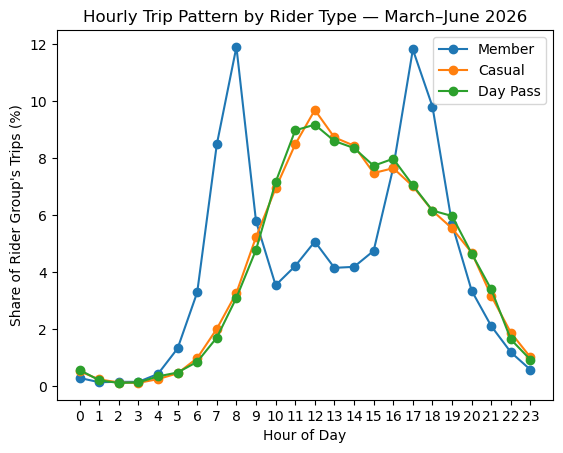

In [25]:
plt.plot(
    hourly_shares.index,
    hourly_shares["member"],
    marker="o",
    label="Member"
)

plt.plot(
    hourly_shares.index,
    hourly_shares["casual"],
    marker="o",
    label="Casual"
)

plt.plot(
    hourly_shares.index,
    hourly_shares["day_pass"],
    marker="o",
    label="Day Pass"
)

plt.title("Hourly Trip Pattern by Rider Type — March–June 2026")
plt.xlabel("Hour of Day")
plt.ylabel("Share of Rider Group's Trips (%)")
plt.xticks(range(0, 24))
plt.legend()

plt.savefig(
    "charts/day_pass_hourly_profile.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

### D5. Behavioral Verdict on Day Pass Riders

Day Pass riders behave much more like leisure-oriented casual riders than members. Their median trip duration is about 20.5 minutes, which is close to the casual-rider median of about 19.1 minutes and substantially longer than the member median of about 11.7 minutes. The upper end of the duration distribution shows the same general pattern.

The timing of trips also differs from member behavior. Members show stronger morning and evening commute peaks, while Day Pass and casual riders are more concentrated from late morning through the afternoon. Weekend use provides the clearest distinction: about 61% of Day Pass trips occur on weekends, compared with roughly 29% for both casual riders and members.

**Verdict:** The behavioral evidence suggests that the Day Pass is mainly attracting a leisure-oriented non-member segment rather than simply replacing routine member trips. This reduces concern about strong membership cannibalization, although the trip data cannot determine whether individual Day Pass users would otherwise have purchased memberships.

## Part E — Memo to the Director of Operations

**To:** Director of Operations, Ride Knox
**From:** Raymond Kojo Kyei
**Subject:** Review of the Day Pass and Station Capacity, January–June 2026

### 1. Bottom line
Based on the first six months of 2026, the Day Pass appears to be helping Ride Knox rebuild non-member ridership, while the capacity changes also reduced pressure at several important stations.

### 2. Evidence
Ride Knox recorded 57,624 casual trips from January through June 2025. In the same period of 2026, casual trips fell to 45,586, but adding 10,941 Day Pass trips gives 56,527 non-member trips, only 1.9% below the 57,624-trip 2025 baseline. Campus pressure also declined: S06 fell from 3.81 to 2.60 trip starts per dock per day and S08 from 3.69 to 2.49. S23 improved strongly, S24 remained low, and new station S25 reached 3.29 trips per dock per day.

### 3. Interpretation
**Interpretation:** Day Pass riders behave more like leisure-oriented casual riders than members. Median trip duration was 20.53 minutes for Day Pass riders, 19.08 for casual riders, and 11.65 for members. Weekend use was especially distinctive: 6,703 of 10,941 Day Pass trips, or 61.3%, occurred on weekends.

### 4. Limitations
These results have several limits. The analysis covers only six months of 2026, the data are observational and cannot prove cause and effect, known data-quality problems remain in the 2026 file, and the trip log cannot show whether individual Day Pass users would otherwise have purchased memberships.

### 5. Recommendation
I recommend continuing the Day Pass and maintaining the expanded campus capacity. Keep S23, continue monitoring S24 before relocating it, and track S25 and membership trends over a longer period for evidence of cannibalization.



### Reflection

The decision that could most change my conclusion was how I defined non-member ridership in 2026. If I considered only casual trips, ridership was about 20.9% below the January–June 2025 level. When I included Day Pass trips as part of the non-member market, however, the difference narrowed to about 1.9%. This showed me that the conclusion about recovery depends strongly on how the new Day Pass category is treated. I therefore reported both definitions instead of relying only on the one that produced the more favorable result.

### AI Disclosure

I used ChatGPT to help interpret the project requirements, draft and troubleshoot parts of the Python code, organize the analysis, check whether my comparisons were fair, interpret outputs, and improve the clarity of some written explanations. I ran and reviewed the code and outputs myself and checked the final conclusions against the results.